# CNN com transformada Wavelet no Pipeline

## Wavelet Biorthogonal 1.3

Agora vamos variar a wavelet mãe usada para verificar como irá se comportar o modelo.

A wavelet mãe escolhida foi a Biorthogonal, pois é uma função muito citada em artigos que utilizam a wavelet como realce de características, ou seja, espera-se que tenhamos um resultado melhor de acurácia.

A função wavelet Biorthogonal tem esse formato:

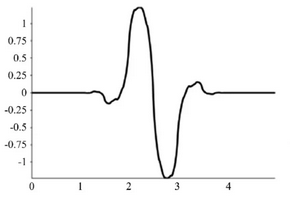

Percebe-se que é uma função com bordas de transição mais suaves, o que ao contrário da Haar (que é muito "quadrada"), as Biorthogonal possuem funções de reconstrução e decomposição diferentes. Isso permite que elas capturem texturas suaves e bordas de nódulos de forma muito mais precisa.

## Implementação da Camada Wavelet Biorthogonal 1.3

Abaixo código da camada implementada, sendo a Bior 1.3, da qual possue filtros de decomposição para extrair as 4 sub-bandas (Aproximação, Horizontal, Vertical e Diagonal).

### Com Wavelet Treinável e Stride = 2

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt
import numpy as np

class WaveletPoolingBior(nn.Module):
    def __init__(self, in_channels):
        super(WaveletPoolingBior, self).__init__()
        self.in_channels = in_channels
        
        # ================================
        # 1. Wavelet BIORTHOGONAL 1.3
        # ================================
        wavelet = pywt.Wavelet('bior1.3') 
        
        dec_lo = np.array(wavelet.dec_lo)
        dec_hi = np.array(wavelet.dec_hi)

        # ================================
        # 2. Filtros 2D
        # ================================
        ll = np.outer(dec_lo, dec_lo)
        lh = np.outer(dec_lo, dec_hi)
        hl = np.outer(dec_hi, dec_lo)
        hh = np.outer(dec_hi, dec_hi)

        filters = np.stack([ll, lh, hl, hh], axis=0)
        filters = torch.tensor(filters, dtype=torch.float32).unsqueeze(1)

        # ================================
        # 3. Expandir para canais
        # ================================
        initial_weights = filters.repeat(in_channels, 1, 1, 1)

        # manter congelado inicialmente
        self.weight = nn.Parameter(initial_weights, requires_grad=False)

        # ================================
        # 4. Padding correto (IMPORTANTE)
        # ================================
        kernel_size = filters.shape[-1]
        self.padding = kernel_size // 2  

    def forward(self, x):
        return F.conv2d(
            x,
            self.weight,
            stride=2,
            padding=self.padding,
            groups=self.in_channels
        )

## Convolutional Block Attention Module (CBAM)

O Convolutional Block Attention Module é um módulo que:

- refina o mapa de features aplicando atenção em duas dimensões:
    - CANAL → “O QUE é importante”
    - ESPACIAL → “ONDE é importante”

## Channel Attention

In [2]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, H, W = x.size()

        avg_pool = torch.mean(x, dim=(2,3))        # [B, C]
        max_pool, _ = torch.max(x.view(B, C, -1), dim=2)

        avg_out = self.mlp(avg_pool)
        max_out = self.mlp(max_pool)

        out = avg_out + max_out
        out = self.sigmoid(out).view(B, C, 1, 1)

        return x * out

## Spatial Attention

In [3]:
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)

        concat = torch.cat([avg, maxv], dim=1)
        att = self.sigmoid(self.conv(concat))

        return x * att

## CBAM completo

In [4]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

## Etapa de CLASSIFICAÇÃO + DATALOADER + ROI

- Classificando as imagnes do Dataset mini-mias

- Carregando dataset para CNN aplicando Data Augmentation (aumento de dados)
    - Efetuado ainda mais variações nas imagens (data augmentation) para conseguir aumentar o dataset.

- Ajustando a **região de interesse (ROI)** para que a rede possa aprender apenas olhando para o artefato.

### Região de interesse - ROI

Em vez de analisar a imagem inteira, o modelo identifica áreas específicas onde há uma alta probabilidade de existir algo interessante (um carro, uma pessoa, uma célula) ou no nosso caso um artefato na região mamária. Essas áreas são as "Regiões de Interesse".

Total de imagens encontradas: 322

===== SPLIT =====
Train com nódulo: 80
Test com nódulo: 35
Train sem nódulo: 143
Test sem nódulo: 62

Mostrando exemplos de ROI...


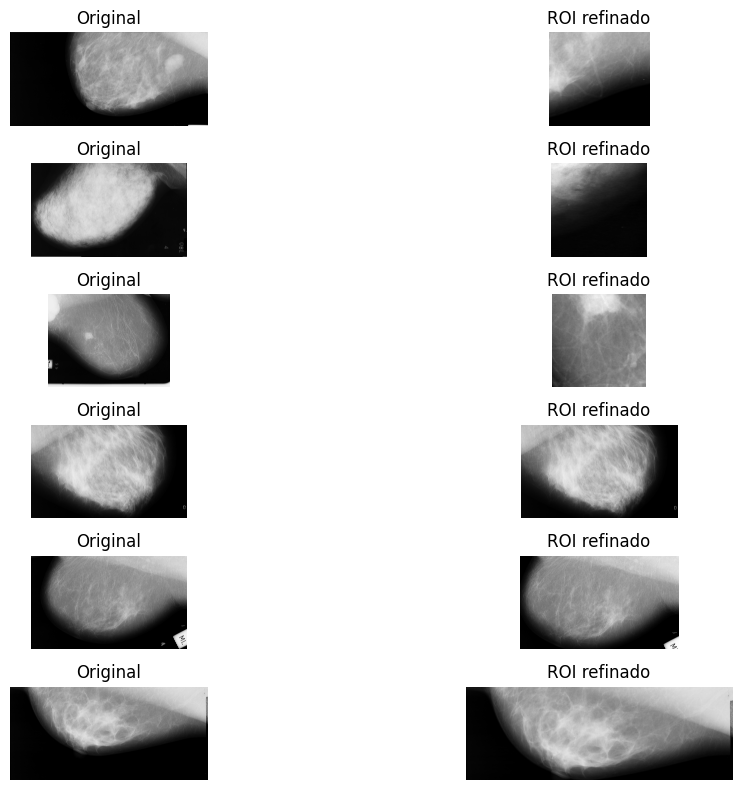


PIPELINE COMPLETO COM ROI + BALANCEAMENTO PRONTO!


In [5]:
import os
import random
import shutil
from PyPDF2 import PdfReader

import cv2
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ================================
# CONFIG
# ================================
PASTA_MIAs = "dataset-mias"
OUTPUT_DATASET = "dataset"
PDF_PATH = os.path.join(PASTA_MIAs, "00README.pdf")

# ================================
# 1. PEGAR IMAGENS
# ================================
todas_imagens = sorted([
    f for f in os.listdir(PASTA_MIAs)
    if f.endswith(".pgm")
])

print(f"Total de imagens encontradas: {len(todas_imagens)}")

# ================================
# 2. LER PDF (CLASSE + ROI)
# ================================
reader = PdfReader(PDF_PATH)

texto_total = ""
for pagina in reader.pages:
    txt = pagina.extract_text()
    if txt:
        texto_total += txt + "\n"

linhas = texto_total.split("\n")

mapa_classes = {}
mapa_roi = {}

for linha in linhas:
    linha = linha.strip()

    if linha.startswith("mdb"):
        partes = linha.split()

        if len(partes) >= 3:
            nome = partes[0] + ".pgm"
            classe = partes[2]

            mapa_classes[nome] = classe

            # ROI só se existir
            if len(partes) >= 7:
                try:
                    x = int(partes[4])
                    y = int(partes[5])
                    r = int(partes[6])
                    mapa_roi[nome] = (x, y, r)
                except:
                    mapa_roi[nome] = None
            else:
                mapa_roi[nome] = None
# ================================
# 3. FUNÇÃO ROI
# ================================
def extrair_roi_mias(img, roi_info):
    h, w = img.shape[:2]

    # ================================
    # 1. REMOVER FUNDO (segmentar mama)
    # ================================
    _, thresh = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        c = max(contours, key=cv2.contourArea)
        x_m, y_m, w_m, h_m = cv2.boundingRect(c)

        img = img[y_m:y_m+h_m, x_m:x_m+w_m]

        # ajustar ROI para nova referência
        if roi_info is not None:
            x, y, r = roi_info
            x -= x_m
            y -= y_m
            roi_info = (x, y, r)

    # ================================
    # 2. SE NÃO TEM ROI → retorna mama
    # ================================
    if roi_info is None:
        return img

    x, y, r = roi_info

    # ================================
    # 3. EXPANSÃO INTELIGENTE
    # ================================
    r = int(r * 2.0)

    x1 = max(0, int(x - r))
    y1 = max(0, int(y - r))
    x2 = min(img.shape[1], int(x + r))
    y2 = min(img.shape[0], int(y + r))

    roi = img[y1:y2, x1:x2]

    # ================================
    # 4. VALIDAÇÃO
    # ================================
    if roi.shape[0] < 64 or roi.shape[1] < 64:
        return img

    if np.mean(roi) < 10:
        return img

    return roi

# ================================
# 4. CLASSIFICAÇÃO
# ================================
com_nodulo = []
sem_nodulo = []

for nome in todas_imagens:
    classe = mapa_classes.get(nome, None)

    if classe is None:
        continue
    elif classe == "NORM":
        sem_nodulo.append(nome)
    else:
        com_nodulo.append(nome)

# ================================
# 5. LIMPAR DATASET
# ================================
shutil.rmtree(OUTPUT_DATASET, ignore_errors=True)

os.makedirs("dataset/train/com_nodulo", exist_ok=True)
os.makedirs("dataset/train/sem_nodulo", exist_ok=True)
os.makedirs("dataset/test/com_nodulo", exist_ok=True)
os.makedirs("dataset/test/sem_nodulo", exist_ok=True)

# ================================
# 6. SPLIT + ROI AQUI 
# ================================
def dividir(lista, pasta_train, pasta_test, mostrar_roi=False):
    random.shuffle(lista)
    corte = int(0.7 * len(lista))

    train = lista[:corte]
    test = lista[corte:]

    exemplos_roi = []

    def processar(lista_nomes, pasta_destino):
        for nome in lista_nomes:
            caminho = os.path.join(PASTA_MIAs, nome)

            img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)

            roi_info = mapa_roi.get(nome, None)
            img_roi = extrair_roi_mias(img, roi_info)

            destino = os.path.join(pasta_destino, nome)
            cv2.imwrite(destino, img_roi)

            # guardar alguns exemplos para plot
            if mostrar_roi and len(exemplos_roi) < 6:
                exemplos_roi.append((img, img_roi))

    processar(train, pasta_train)
    processar(test, pasta_test)

    return len(train), len(test), exemplos_roi

# executa divisão + ROI
train_c, test_c, exemplos1 = dividir(com_nodulo, "dataset/train/com_nodulo", "dataset/test/com_nodulo", True)
train_s, test_s, exemplos2 = dividir(sem_nodulo, "dataset/train/sem_nodulo", "dataset/test/sem_nodulo", True)

print("\n===== SPLIT =====")
print(f"Train com nódulo: {train_c}")
print(f"Test com nódulo: {test_c}")
print(f"Train sem nódulo: {train_s}")
print(f"Test sem nódulo: {test_s}")

# ================================
# 7. MOSTRAR ROI (DEBUG VISUAL)
# ================================
def mostrar_exemplos(exemplos):
    plt.figure(figsize=(12, 8))
    
    for i, (orig, roi) in enumerate(exemplos):
        # original com ROI desenhado
        img_draw = cv2.cvtColor(orig, cv2.COLOR_GRAY2BGR)
        
        plt.subplot(len(exemplos), 2, 2*i + 1)
        plt.imshow(img_draw)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(len(exemplos), 2, 2*i + 2)
        plt.imshow(roi, cmap='gray')
        plt.title("ROI refinado")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\nMostrando exemplos de ROI...")
mostrar_exemplos(exemplos1[:3] + exemplos2[:3])

# ================================
# 8. CLAHE
# ================================
class ApplyCLAHE:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __call__(self, img):
        img_np = np.array(img)

        if img_np.ndim == 3:
            img_np = img_np[..., 0]

        img_np = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        img_clahe = self.clahe.apply(img_np)

        return Image.fromarray(img_clahe)

# ================================
# 9. TRANSFORMS
# ================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),

    transforms.GaussianBlur(3),

    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# ================================
# 10. DATASET + DATALOADER
# ================================
train_dataset = datasets.ImageFolder("dataset/train", transform=train_transform)
test_dataset = datasets.ImageFolder("dataset/test", transform=test_transform)

# BALANCEAMENTO AQUI
from torch.utils.data import WeightedRandomSampler

targets = train_dataset.targets
class_count = np.bincount(targets)

class_count[class_count == 0] = 1  # evita divisão por zero

weights = 1. / class_count
sample_weights = [weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print("\nPIPELINE COMPLETO COM ROI + BALANCEAMENTO PRONTO!")

## Modelo com Wavelet Haar + CNN + Attention CBAM + ROI

<img src="img/waveletCNN-modelo15.png" width="800" title="Dica de ferramenta">

In [6]:
"""
MODELO COM A WAVELET SUBSTITUINDO O MAXPOOLING, CONVOLUÇÕES E CBAM
"""
class WaveletCNN_BIOR(nn.Module):
    def __init__(self):
        super().__init__()

        self.wavelet_input = WaveletPoolingBior(in_channels=1)

        self.features = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            CBAM(32), 
            WaveletPoolingBior(in_channels=32),

            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            CBAM(64), 
            WaveletPoolingBior(in_channels=64),

            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            CBAM(128), 
            WaveletPoolingBior(in_channels=128),

        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.wavelet_input(x)
        x = self.features(x)
        x = self.classifier(x)
        return x

#### Antes do treino:

Conta quantas amostras existem de cada classe, é importante isso quando temos um dataset desbalanceado.

In [7]:
from collections import Counter

labels_list = [label for _, label in train_dataset.samples]

class_counts_dict = Counter(labels_list)

print("Distribuição das classes:", class_counts_dict)

num_normal = class_counts_dict[0]
num_cancer = class_counts_dict[1]

Distribuição das classes: Counter({1: 143, 0: 80})


## Treinando o modelo

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Modelo
model = WaveletCNN_BIOR()

# 2. Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Loss com balanceamento
class_counts = [num_normal, num_cancer]

weights = 1. / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# 4. Otimizador
"""
    "lr" = learning rate -> refere-se ao quanto o modelo irá mudar os pesos a cada erro que tiver
"""
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# 5. Scheduler 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    corretos_treino = 0
    total_treino = 0
    
    for imagens, labels in train_loader:
        imagens, labels = imagens.to(device), labels.to(device)
        
        outputs = model(imagens)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_treino += labels.size(0)
        corretos_treino += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * corretos_treino / total_treino
    
    print(f"Época [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Acc Treino: {epoch_acc:.2f}%")

    scheduler.step(epoch_loss)

    # Validação
    if (epoch + 1) % 5 == 0:
        model.eval()
        corretos_teste = 0
        total_teste = 0

        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                _, pred = torch.max(out, 1)

                total_teste += lbls.size(0)
                corretos_teste += (pred == lbls).sum().item()

        print(f">>> Acurácia de Teste: {100 * corretos_teste / total_teste:.2f}%")

Época [1/50] - Loss: 0.6799 - Acc Treino: 47.53%
Época [2/50] - Loss: 0.6446 - Acc Treino: 52.47%
Época [3/50] - Loss: 0.6530 - Acc Treino: 44.39%
Época [4/50] - Loss: 0.6474 - Acc Treino: 47.98%
Época [5/50] - Loss: 0.6092 - Acc Treino: 48.88%
>>> Acurácia de Teste: 36.08%
Época [6/50] - Loss: 0.5688 - Acc Treino: 52.02%
Época [7/50] - Loss: 0.5727 - Acc Treino: 46.19%
Época [8/50] - Loss: 0.5237 - Acc Treino: 53.81%
Época [9/50] - Loss: 0.4698 - Acc Treino: 68.16%
Época [10/50] - Loss: 0.4805 - Acc Treino: 73.09%
>>> Acurácia de Teste: 76.29%
Época [11/50] - Loss: 0.3945 - Acc Treino: 80.72%
Época [12/50] - Loss: 0.3389 - Acc Treino: 88.34%
Época [13/50] - Loss: 0.3956 - Acc Treino: 79.82%
Época [14/50] - Loss: 0.3368 - Acc Treino: 82.96%
Época [15/50] - Loss: 0.3879 - Acc Treino: 78.92%
>>> Acurácia de Teste: 81.44%
Época [16/50] - Loss: 0.3715 - Acc Treino: 82.96%
Época [17/50] - Loss: 0.3270 - Acc Treino: 87.00%
Época [18/50] - Loss: 0.3853 - Acc Treino: 83.86%
Época [19/50] - Los

## Testando o modelo

In [9]:
model.eval()
corretos = 0
total = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for imagens, labels in test_loader:
        
        imagens, labels = imagens.to(device), labels.to(device)

        outputs = model(imagens)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        corretos += (predicted == labels).sum().item()

print(f"Acurácia: {100 * corretos / total:.2f}%")

Acurácia: 89.69%
